here i did loading and combining the cleaned datas for comparison

In [4]:
import pandas as pd

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria])

here i did the temperature  comparsion graph and it shows that sudan has highest average temperatures

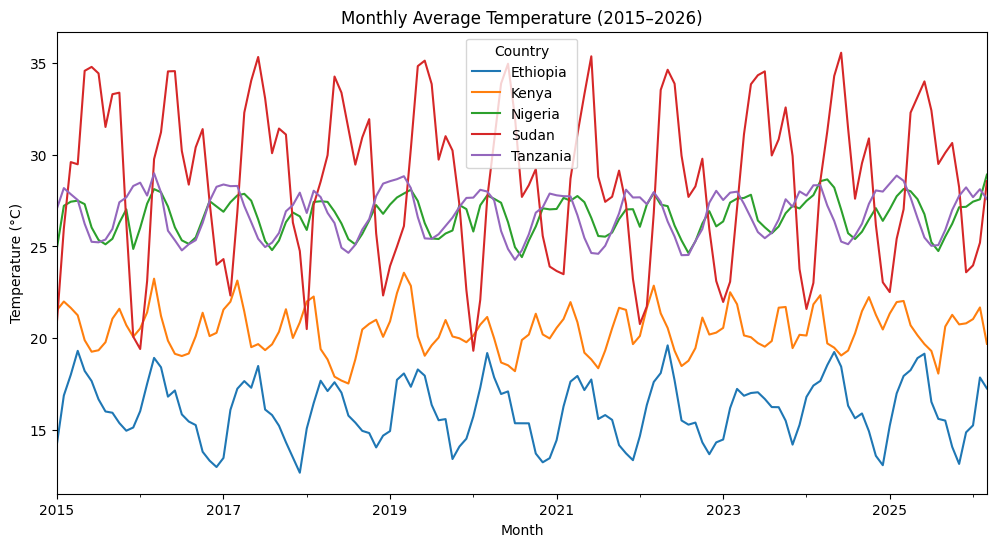

In [5]:
import matplotlib.pyplot as plt

df["DATE"] = pd.to_datetime(df["DATE"])
df["Month"] = df["DATE"].dt.to_period("M")

monthly_temp = df.groupby(["Month", "Country"])["T2M"].mean().unstack()

monthly_temp.plot(figsize=(12, 6))
plt.title("Monthly Average Temperature (2015–2026)")
plt.ylabel("Temperature (°C)")
plt.show()

In [6]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


here i did the rainfall comparsion graph tanzania exhibits high variability in precipitation

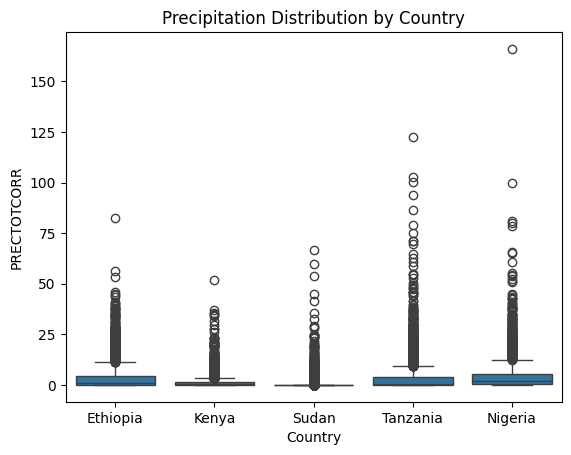

In [7]:
import seaborn as sns

sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Distribution by Country")
plt.show()

In [8]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(
    ["mean", "median", "std"])
rain_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


here we see extreme events like heat days which is exhibited by sudan 

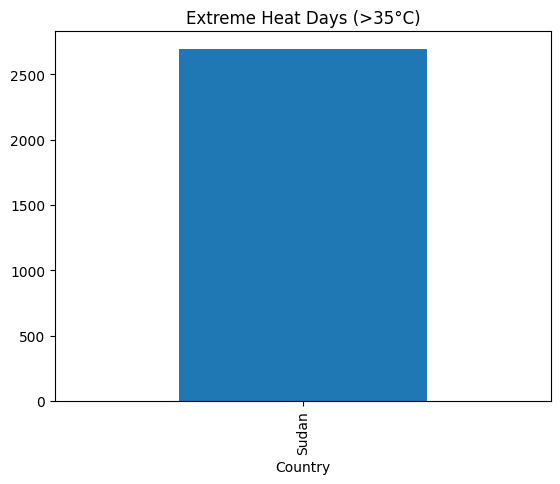

In [9]:
df["Year"] = df["DATE"].dt.year

extreme_heat = df[df["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby("Country").size()
heat_counts.plot(kind="bar", title="Extreme Heat Days (>35°C)")
plt.show()

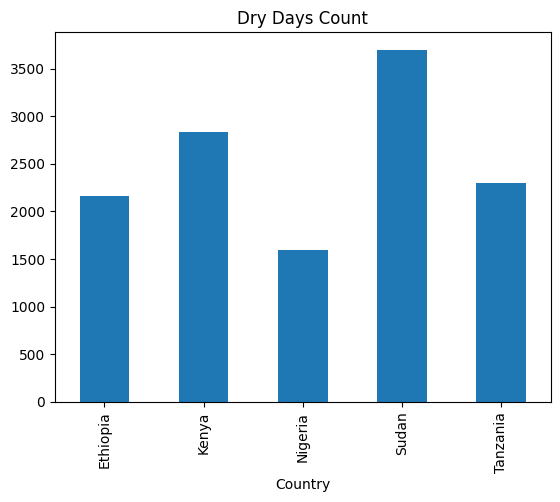

In [10]:
dry_days = df[df["PRECTOTCORR"] < 1]

dry_counts = dry_days.groupby("Country").size()
dry_counts.plot(kind="bar", title="Dry Days Count")
plt.show()

Sudan should be prioritized for climate finance due to its high temperature extremes and drought frequency

In [12]:
from scipy.stats import f_oneway

groups = [group["T2M"].dropna() for name, group in df.groupby("Country")]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 18938.7456970699
p-value: 0.0


In [13]:
ranking = pd.DataFrame({
    "Temp_Mean": temp_summary["mean"],
    "Rain_Variability": rain_summary["std"],
    "Extreme_Heat": heat_counts,
    "Dry_Days": dry_counts
})

ranking

,Temp_Mean,Rain_Variability,Extreme_Heat,Dry_Days
Country,,,,
Ethiopia,16.068500,6.289061,NaN,2161
Kenya,20.427600,3.180228,NaN,2831
Nigeria,26.656928,7.266742,NaN,1595
Sudan,28.759007,3.057672,2694.0,3696
Tanzania,26.802422,8.003947,NaN,2303
